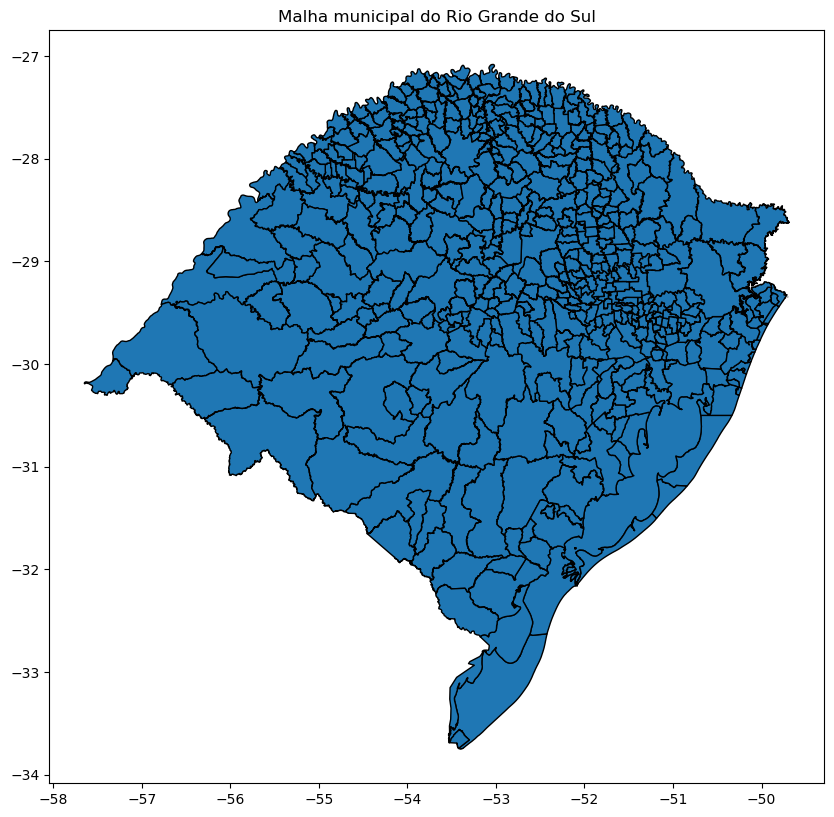

Dropdown(description='Município:', layout=Layout(width='50%'), options=('Aceguá', 'Agudo', 'Ajuricaba', 'Alecr…

Button(description='Exportar Município', style=ButtonStyle())

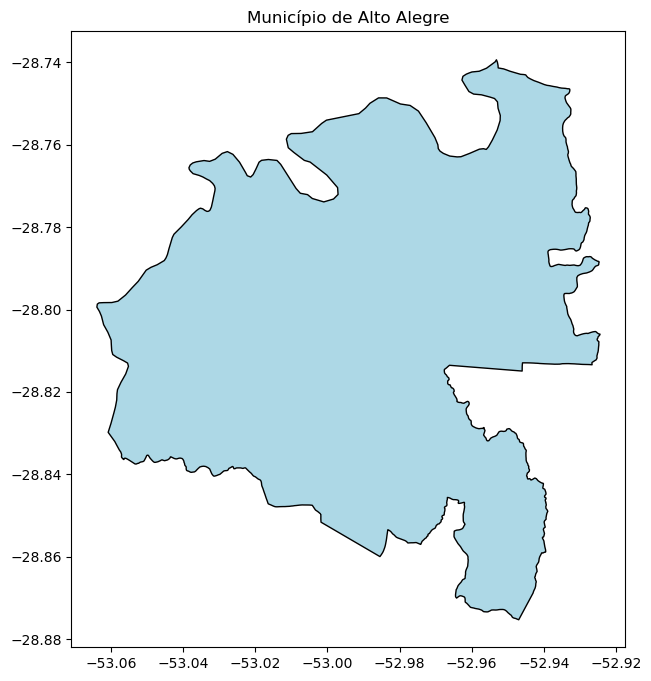

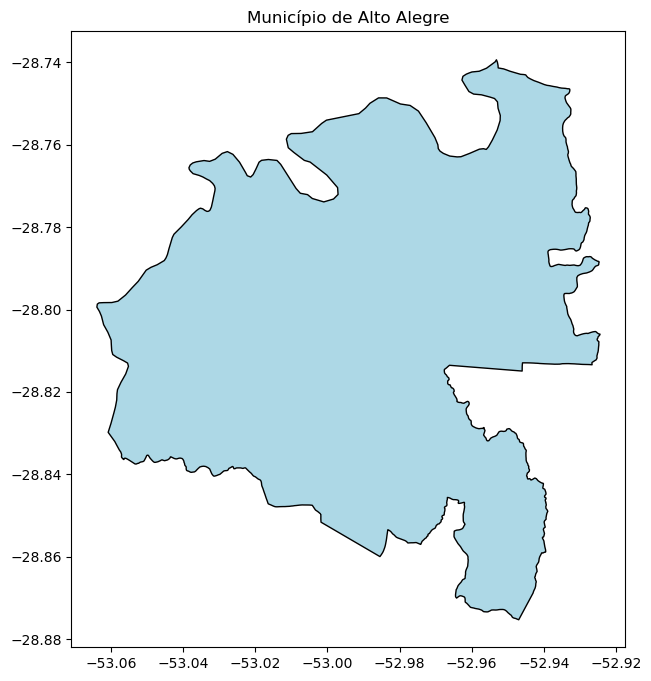

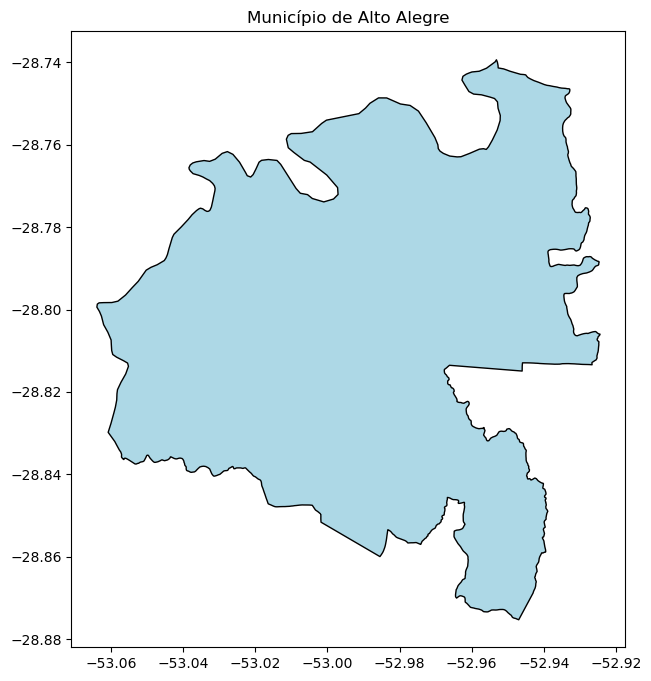

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Carregar o shapefile
shapefile_path = r'D:\projetos\data\shapefiles\brasil\RS_Municipios_2024\sul\rs\RS_Municipios_2024.shp'
gdf = gpd.read_file(shapefile_path)

# Plotar o mapa do estado (opcional)
gdf.plot(figsize=(10,10), edgecolor='black')
plt.title("Malha municipal do Rio Grande do Sul")
plt.show()

# Lista de municípios disponíveis
municipios = sorted(gdf['NM_MUN'].unique())

# Criar dropdown
dropdown = widgets.Dropdown(
    options=municipios,
    description='Município:',
    layout=widgets.Layout(width='50%')
)

# Função para filtrar, plotar e exportar o município selecionado
def filtrar_municipio(municipio_nome):
    municipio_filtrado = gdf[gdf["NM_MUN"] == municipio_nome]
    
    if municipio_filtrado.empty:
        print(f"Município '{municipio_nome}' não encontrado!")
    else:
        municipio_filtrado.plot(figsize=(8,8), edgecolor='black', color='lightblue')
        plt.title(f"Município de {municipio_nome}")
        plt.show()

        output_path = rf'D:\projetos\outputs\shapefiles\brasil\sul\rs\{municipio_nome}.gpkg'
        municipio_filtrado.to_file(output_path, driver='GPKG')
        print(f"Arquivo {municipio_nome}.gpkg salvo em {output_path}")

# Botão de executar
botao = widgets.Button(description="Exportar Município")

# Função ao clicar no botão
def on_button_click(b):
    filtrar_municipio(dropdown.value)

botao.on_click(on_button_click)

# Mostrar widgets
display(dropdown, botao)
